# Regression: Linear & Logistic

## 📈 Part 1 — Linear Regression

So far we've done **classification**: predicting a *category* (girl/boy).
**Regression** predicts a *continuous number*.

Example: back to Mr. Tavasoli's lab — suppose the tav-hormone level increases with
the **week of pregnancy**. Given the week, can we predict the expected hormone level?

### The model

Linear regression assumes the target is (approximately) a linear function of the input:

$$\hat{y} = w_0 + w_1 x$$

- $w_1$: slope (weight)
- $w_0$: intercept (bias)

With multiple features: $\hat{y} = w_0 + w_1 x_1 + \dots + w_d x_d = \mathbf{w}^\top \mathbf{x} + w_0$

### The loss: Mean Squared Error

We find $\mathbf{w}$ by minimizing the **MSE**:

$$\mathcal{L}(w_0, w_1) = \frac{1}{n}\sum_{i=1}^{n} \big(y_i - (w_0 + w_1 x_i)\big)^2$$

This has a closed-form solution (the *normal equations*), and for simple 1D regression:

$$w_1 = \frac{\sum (x_i - \bar x)(y_i - \bar y)}{\sum (x_i - \bar x)^2}, \qquad w_0 = \bar y - w_1 \bar x$$

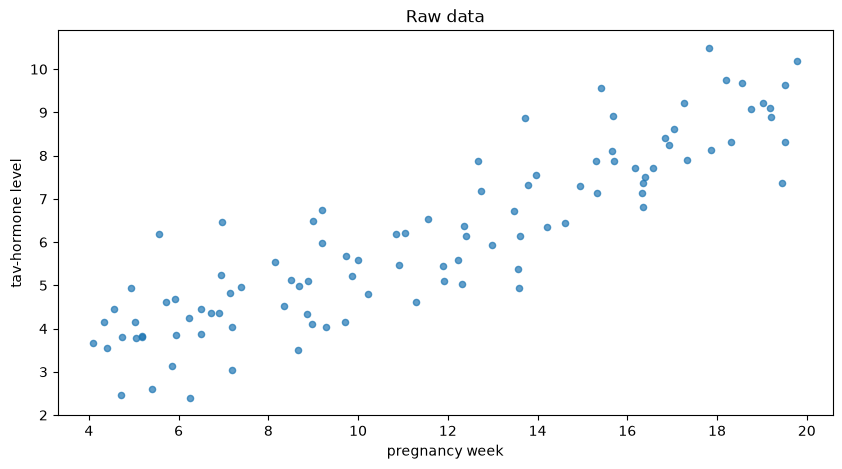

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)

# Synthetic data: hormone level vs pregnancy week
n = 100
week = np.random.uniform(4, 20, n)
hormone = 1.5 + 0.4 * week + np.random.normal(0, 1.0, n)

plt.scatter(week, hormone, s=20, alpha=0.7)
plt.xlabel("pregnancy week"); plt.ylabel("tav-hormone level")
plt.title("Raw data"); plt.show()

### Fitting by hand (from the formulas)

In [2]:
w1 = np.sum((week - week.mean()) * (hormone - hormone.mean())) / np.sum((week - week.mean())**2)
w0 = hormone.mean() - w1 * week.mean()
print(f"Manual fit:  y = {w0:.3f} + {w1:.3f} * x")

Manual fit:  y = 1.830 + 0.371 * x


### Fitting with scikit-learn

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = week.reshape(-1, 1)   # sklearn expects 2D features
lr = LinearRegression().fit(X, hormone)

print(f"sklearn fit: y = {lr.intercept_:.3f} + {lr.coef_[0]:.3f} * x")

y_pred = lr.predict(X)
print(f"MSE = {mean_squared_error(hormone, y_pred):.3f}")
print(f"R²  = {r2_score(hormone, y_pred):.3f}")

sklearn fit: y = 1.830 + 0.371 * x
MSE = 0.807
R²  = 0.793


In [12]:
def mean_squared_error_simple( y_model, y_real) :
    return ((y_model - y_real)**2).mean()
    
mean_squared_error_simple(hormone, y_pred)

np.float64(0.8065845639670531)

In [ ]:
xs = np.linspace(4, 20, 100).reshape(-1, 1)
plt.scatter(week, hormone, s=20, alpha=0.6, label="data")
plt.plot(xs, lr.predict(xs), "r-", lw=2, label="fitted line")

# Show residuals for a few points
for i in range(0, n, 10):
    plt.plot([week[i], week[i]], [hormone[i], y_pred[i]], "g-", alpha=0.5)

plt.xlabel("pregnancy week"); plt.ylabel("tav-hormone level")
plt.legend(); plt.title("Linear regression minimizes squared residuals (green)")
plt.show()

### Interpreting $R^2$

$R^2$ = fraction of the variance in $y$ explained by the model.
$R^2 = 1$ → perfect fit; $R^2 = 0$ → no better than predicting the mean.

## 🎲 Part 2 — Logistic Regression

Despite the name, logistic regression is a **classification** algorithm!
It connects back to our first lesson: it directly models the **posterior probability**

$$P(\text{class}=1 \mid x)$$

### Why not use linear regression for classification?

A line $w_0 + w_1 x$ outputs values in $(-\infty, +\infty)$ — but a probability must
be in $[0, 1]$. The fix: squash the line through the **sigmoid** function.

### The sigmoid function

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- $\sigma(0) = 0.5$
- $z \to +\infty \Rightarrow \sigma(z) \to 1$
- $z \to -\infty \Rightarrow \sigma(z) \to 0$

In [ ]:
z = np.linspace(-8, 8, 200)
sigmoid = 1 / (1 + np.exp(-z))

plt.plot(z, sigmoid)
plt.axhline(0.5, ls=":", color="gray"); plt.axvline(0, ls=":", color="gray")
plt.xlabel("z"); plt.ylabel("σ(z)"); plt.title("The sigmoid function")
plt.show()

### The model

$$P(y=1 \mid x) = \sigma(w_0 + w_1 x) = \frac{1}{1 + e^{-(w_0 + w_1 x)}}$$

Equivalently, the model is **linear in the log-odds**:

$$\log\frac{P(y=1\mid x)}{P(y=0\mid x)} = w_0 + w_1 x$$

The decision boundary is where $P = 0.5$, i.e. where $w_0 + w_1 x = 0$ — a point in
1D, a line in 2D, a hyperplane in general.

### The loss: cross-entropy (log loss)

There is no closed form; we minimize the **negative log-likelihood**:

$$\mathcal{L}(\mathbf{w}) = -\frac{1}{n}\sum_{i=1}^n \Big[ y_i \log \hat p_i + (1-y_i)\log(1-\hat p_i) \Big], \quad \hat p_i = \sigma(w_0 + w_1 x_i)$$

This is solved numerically (gradient descent / quasi-Newton) — scikit-learn handles it.

### Back to the tav-hormone: logistic regression in scikit-learn

In [ ]:
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# The same dataset as notebooks 1 & 2
P_GIRL, P_BOY = 0.7, 0.3
girl_dist, boy_dist = stats.norm(4.0, 1.2), stats.norm(7.0, 1.5)

n = 2000
n_girls = int(n * P_GIRL)
Xc = np.concatenate([girl_dist.rvs(n_girls), boy_dist.rvs(n - n_girls)]).reshape(-1, 1)
yc = np.array([0] * n_girls + [1] * (n - n_girls))  # 0 = girl, 1 = boy

X_train, X_test, y_train, y_test = train_test_split(Xc, yc, test_size=0.3,
                                                    random_state=0, stratify=yc)

logreg = LogisticRegression().fit(X_train, y_train)
print(f"w0 = {logreg.intercept_[0]:.3f}, w1 = {logreg.coef_[0,0]:.3f}")
print(f"Decision boundary at x = {-logreg.intercept_[0]/logreg.coef_[0,0]:.3f}")
print(f"Test accuracy: {logreg.score(X_test, y_test):.3f}")

Compare that boundary with the Bayes-optimal intersection point (~6.05) from
notebook 1 — logistic regression recovers it from data!

In [ ]:
grid = np.linspace(0, 12, 500).reshape(-1, 1)
proba = logreg.predict_proba(grid)[:, 1]

# True posterior for reference
num = P_BOY * boy_dist.pdf(grid.ravel())
true_post = num / (num + P_GIRL * girl_dist.pdf(grid.ravel()))

plt.plot(grid, true_post, "k-", lw=2, label="True P(boy | x)")
plt.plot(grid, proba, color="tab:green", lw=2, label="Logistic regression")
plt.axhline(0.5, ls=":", color="gray")
plt.scatter(Xc[yc == 0], np.zeros(n_girls), c="deeppink", s=5, alpha=0.3)
plt.scatter(Xc[yc == 1], np.ones(n - n_girls), c="navy", s=5, alpha=0.3)
plt.xlabel("tav-hormone level"); plt.ylabel("P(boy | x)")
plt.legend(); plt.title("Logistic regression estimates the posterior")
plt.show()

### Evaluation beyond accuracy

In [ ]:
y_pred = logreg.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["girl", "boy"]))

## 🧠 Key takeaways

| | Linear regression | Logistic regression |
|---|---|---|
| Task | Regression (continuous $y$) | Classification (probability of class) |
| Output | $w^\top x + w_0 \in \mathbb{R}$ | $\sigma(w^\top x + w_0) \in (0,1)$ |
| Loss | Mean Squared Error | Cross-entropy (log loss) |
| Solution | Closed form | Iterative optimization |
| Boundary | — | Linear (hyperplane) |

1. Linear regression fits a line by minimizing squared errors.
2. Logistic regression = linear model + sigmoid → outputs a **probability**.
3. Like KNN, logistic regression estimates $P(\text{class}\mid x)$ — but with a **parametric**, linear assumption. When that assumption holds, it needs far less data; when it doesn't, KNN's flexibility wins.
4. Everything connects back to the tav-hormone lesson: good classifiers approximate the **Bayes posterior**.